In [81]:
import os

# Manually fix the project root if current working directory is wrong
proj_root = "C:/Users/mahas/rogueshield-ai-threat-detector"
os.chdir(proj_root)  # change working directory to project root

print("Working directory set to:", os.getcwd())


Working directory set to: C:\Users\mahas\rogueshield-ai-threat-detector


In [80]:
import os
import numpy as np
import matplotlib.pyplot as plt
import shap
import tensorflow as tf

# Ensure reproducibility (optional)
np.random.seed(42)
tf.random.set_seed(42)

# Compute project root
proj_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))


In [79]:

# ── Cell: Recreate Multiclass Split on attack_cat & Save X_val_intr, y_val_intr ──

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, StringLookup, Normalization, Concatenate
from tensorflow.keras import Model

# 1) Compute project root (two levels above this notebook)
proj_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))

# 2) Load the raw UNSW-NB15 “training-set” CSV
train_csv = "C:/Users/mahas/rogueshield-ai-threat-detector/data/UNSW_NB15_training-set.csv"
df_train = pd.read_csv(train_csv, encoding="latin1")

# 3) Drop the BOM-prefixed 'ï»¿id' column, then separate features & labels
if "ï»¿id" in df_train.columns:
    df_train = df_train.drop("ï»¿id", axis=1)

#    Now drop 'attack_cat' and 'label' from features
X_df = df_train.drop(['attack_cat', 'label'], axis=1).copy()
y_raw = df_train['attack_cat']   # multiclass target

# 4) Define categorical vs numeric columns (exactly as in Phase 2)
CATEGORICAL_FEATURES = ['proto', 'service', 'state']
NUMERIC_FEATURES     = [col for col in X_df.columns if col not in CATEGORICAL_FEATURES]

# 5) Build a Keras preprocessing model (StringLookup + Normalization)
inputs = {}
encoded_feats = []

# 5a) One-hot encode categorical columns
for col in CATEGORICAL_FEATURES:
    inp = Input(shape=(1,), name=col, dtype="string")
    lookup = StringLookup(output_mode="one_hot", name=f"{col}_lookup")
    # Adapt on stringified values of that column
    lookup.adapt(X_df[col].astype(str).values)
    onehot = lookup(inp)
    inputs[col] = inp
    encoded_feats.append(onehot)

# 5b) Normalize numeric columns
for col in NUMERIC_FEATURES:
    inp = Input(shape=(1,), name=col, dtype="float32")
    norm = Normalization(name=f"{col}_norm")
    norm.adapt(X_df[col].values.reshape(-1, 1))
    normed = norm(inp)
    inputs[col] = inp
    encoded_feats.append(normed)

# 5c) Concatenate all preprocessed features
preprocessed = Concatenate(name="concat_preprocessed")(encoded_feats)
preprocessing_model = Model(inputs=inputs, outputs=preprocessed)
print("Preprocessing model created. Output shape:", preprocessing_model.output_shape)

# 6) Prepare the dict of arrays for only those input columns (drop anything else)
feed_dict = {}
for col in CATEGORICAL_FEATURES:
    # Convert to string dtype before feeding
    feed_dict[col] = X_df[col].astype(str).values
for col in NUMERIC_FEATURES:
    feed_dict[col] = X_df[col].values.astype(np.float32)

# 7) Apply the preprocessing model to get a NumPy array of shape (N, num_features)
X_all_intr = preprocessing_model.predict(feed_dict, batch_size=1024)
print("X_all_intr shape after preprocessing:", X_all_intr.shape)

# 8) Encode y_raw (strings) into one-hot vectors to match the DNN’s output
le = LabelEncoder()
y_int = le.fit_transform(y_raw.values)              # e.g. ["DoS","Probe",…] → [0,2,5,…]
y_all_intr = np.eye(len(le.classes_))[y_int]         # shape (N, num_classes)
print("y_all_intr shape (one-hot):", y_all_intr.shape)

# 9) Split into train / validation / test (70% / 15% / 15%), stratify by class
X_temp, X_test_intr, y_temp, y_test_intr = train_test_split(
    X_all_intr, y_all_intr,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=y_int
)
val_frac_intr = 0.15 / 0.85
X_train_intr, X_val_intr, y_train_intr, y_val_intr = train_test_split(
    X_temp, y_temp,
    test_size=val_frac_intr,
    random_state=42,
    shuffle=True,
    stratify=np.argmax(y_temp, axis=1)
)

print("Shapes after split:")
print("  X_val_intr:", X_val_intr.shape, "y_val_intr:", y_val_intr.shape)
print("  X_test_intr:", X_test_intr.shape, "y_test_intr:", y_test_intr.shape)

# 10) Save the validation arrays so SHAP can load them
out_dir = os.path.join(proj_root, "data", "processed", "intrusion_features")
os.makedirs(out_dir, exist_ok=True)

np.save(os.path.join(out_dir, "X_val.npy"), X_val_intr)
np.save(os.path.join(out_dir, "y_val.npy"), y_val_intr)
# (Optionally save the test set too)
np.save(os.path.join(out_dir, "X_test.npy"), X_test_intr)
np.save(os.path.join(out_dir, "y_test.npy"), y_test_intr)

print("\n Saved X_val.npy and y_val.npy under data/processed/intrusion_features/")





Preprocessing model created. Output shape: (None, 193)
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
X_all_intr shape after preprocessing: (82332, 193)
y_all_intr shape (one-hot): (82332, 10)
Shapes after split:
  X_val_intr: (12350, 193) y_val_intr: (12350, 10)
  X_test_intr: (12350, 193) y_test_intr: (12350, 10)

 Saved X_val.npy and y_val.npy under data/processed/intrusion_features/


In [77]:
proj_root = r"C:\Users\mahas\rogueshield-ai-threat-detector"

import os

# Correct path
models_dir = os.path.join(proj_root, "models")
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "preprocessing_model.keras")
preprocessing_model.save(model_path)
print(f"Preprocessing model saved to: {model_path}")




Preprocessing model saved to: C:\Users\mahas\rogueshield-ai-threat-detector\models\preprocessing_model.keras


In [76]:
import os

csv_path = os.path.join("data", "UNSW_NB15_training-set.csv")

if not os.path.exists(csv_path):
    print("Still not found:", csv_path)
    print("Current working directory:", os.getcwd())
    print("Files in processed folder:", os.listdir("data/processed"))
else:
    print("File found:", csv_path)

Still not found: data\UNSW_NB15_training-set.csv
Current working directory: c:\Users\mahas\rogueshield-ai-threat-detector\notebooks\explainability
Files in processed folder: ['X_all_intr.npy', 'y_all_intr.npy']


In [5]:
import os
import numpy as np
import shap
import tensorflow as tf
import matplotlib.pyplot as plt

# 1.1 Compute project root (same as before)
proj_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))

# 1.2 Load the saved intrusion‐classifier model
model_intr = tf.keras.models.load_model(
    os.path.join(proj_root, "models", "intrusion_classifier", "rogueshield_intrusion_model.h5")
)

# 1.3 Load the saved validation arrays
X_val_intr = np.load(os.path.join(proj_root, "data", "processed", "intrusion_features", "X_val.npy"))
y_val_intr = np.load(os.path.join(proj_root, "data", "processed", "intrusion_features", "y_val.npy"))

print("Intrusion model loaded; X_val_intr shape:", X_val_intr.shape)

Intrusion model loaded; X_val_intr shape: (12350, 193)


In [6]:
# 2.1 List numeric feature names
df_train = pd.read_csv(os.path.join(proj_root, "data", "UNSW_NB15_training-set.csv"), encoding="latin1")
if "ï»¿id" in df_train.columns:
    df_train = df_train.drop("ï»¿id", axis=1)
CATEGORICAL_FEATURES = ['proto', 'service', 'state']
NUMERIC_FEATURES     = [col for col in df_train.drop(['attack_cat', 'label'], axis=1).columns
                         if col not in CATEGORICAL_FEATURES]

# 2.2 For each categorical column, get the vocabulary from your StringLookup
feature_names = []
for col in CATEGORICAL_FEATURES:
    # Rebuild the StringLookup exactly as before
    lookup = tf.keras.layers.StringLookup(output_mode="one_hot")
    lookup.adapt(df_train[col].astype(str).values)
    vocab = lookup.get_vocabulary()[1:]  # skip the '[UNK]' token
    # Each category maps to one column per vocab entry
    feature_names += [f"{col}_{cat}" for cat in vocab]

# 2.3 Numeric features stay as-is
feature_names += NUMERIC_FEATURES

print("Number of features:", len(feature_names))

Number of features: 190


In [7]:
import tensorflow as tf

# 1) Re-load df_train to get fresh column lists
proj_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))
train_csv = os.path.join(proj_root, "data", "UNSW_NB15_training-set.csv")
df_train = pd.read_csv(train_csv, encoding="latin1")
if "ï»¿id" in df_train.columns:
    df_train = df_train.drop("ï»¿id", axis=1)

# 2) Define categorical vs numeric exactly as before
CATEGORICAL_FEATURES = ['proto', 'service', 'state']
NUMERIC_FEATURES     = [col for col in df_train.drop(['attack_cat', 'label'], axis=1).columns
                        if col not in CATEGORICAL_FEATURES]

# 3) For each categorical, rebuild its StringLookup and count the vocab size
dim_counts = {}
total_onehot = 0
for col in CATEGORICAL_FEATURES:
    lookup = tf.keras.layers.StringLookup(output_mode="one_hot")
    lookup.adapt(df_train[col].astype(str).values)
    vocab = lookup.get_vocabulary()[1:]   # drop “[UNK]”
    dim_counts[col] = len(vocab)
    total_onehot += len(vocab)

print("One-hot dims per categorical column:")
for col, count in dim_counts.items():
    print(f"  • {col}: {count} dims")
print(f"Total one-hot dims (sum): {total_onehot}")
print(f"Numeric features count: {len(NUMERIC_FEATURES)}")
print(f"Sum of one-hot + numeric dims: {total_onehot + len(NUMERIC_FEATURES)}")

# 4) Compare to X_all_intr shape
print(f"X_all_intr has {X_all_intr.shape[1]} columns total.")
print("Difference:", X_all_intr.shape[1] - (total_onehot + len(NUMERIC_FEATURES)))


One-hot dims per categorical column:
  • proto: 131 dims
  • service: 13 dims
  • state: 7 dims
Total one-hot dims (sum): 151
Numeric features count: 39
Sum of one-hot + numeric dims: 190
X_all_intr has 193 columns total.
Difference: 3


In [8]:
vocab = lookup.get_vocabulary()[1:]


In [9]:
# ── Cell: Prepare Raw Inputs & Background/Test Sets for SHAP ───────────────────

import os
import numpy as np
import pandas as pd
import tensorflow as tf

# 1) Compute project root (two levels above this notebook)
proj_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))

# 2) Load raw UNSW-NB15 training DataFrame and rename BOM-prefixed id
df_train = pd.read_csv(os.path.join(proj_root, "data", "UNSW_NB15_training-set.csv"),
                       encoding="latin1")
if "ï»¿id" in df_train.columns:
    df_train = df_train.rename(columns={"ï»¿id": "id"})

# 3) Categorical feature names (others will be treated as numeric)
CATEGORICAL = ["proto", "service", "state"]

# 4) Load the trained intrusion-classifier model
model_intr = tf.keras.models.load_model(
    os.path.join(proj_root, "models", "intrusion_classifier", "rogueshield_intrusion_model.h5")
)

# 5) Extract model input names (in the correct order)
input_names = [inp.name.split(":")[0] for inp in model_intr.inputs]

# 6) Build a list of raw‐feature arrays matching that order
raw_inputs = []
for name in input_names:
    if name in CATEGORICAL:
        arr = df_train[name].astype(str).values
    else:
        arr = df_train[name].values.astype(np.float32)
    raw_inputs.append(arr.reshape(-1, 1))  # shape: (num_samples, 1)

# 7) Split into background (first 100 rows) and test (rows 100–200)
background_list = [ri[:100] for ri in raw_inputs]
test_list       = [ri[100:200] for ri in raw_inputs]

print("Prepared background_list and test_list for SHAP explainer.")


Prepared background_list and test_list for SHAP explainer.


In [73]:
# Remove 'id' from the feature_names list if it exists
if "id" in feature_names:
    feature_names.remove("id")

print(f"Updated feature_names length: {len(feature_names)}")  # Should now be 193


Updated feature_names length: 193


In [82]:
# Only keep feature_names that are valid in X_val_intr
valid_feature_names = feature_names[:X_val_intr.shape[1]]

# Remove 'id' if it's among the valid features
filtered_indices = [i for i, name in enumerate(valid_feature_names) if name != 'id']

# Slice X_val_intr safely
X_val_intr = X_val_intr[:, filtered_indices]


In [72]:
# Assuming X_val_intr is a list of 194 tensors (each shape (num_samples, 1))
background_list = [x[:100] for x in X_val_intr]   # background: 100 samples
test_list = [x[100:200] for x in X_val_intr]      # samples to explain

print("Input format for SHAP: background and test lists created")


Input format for SHAP: background and test lists created


In [13]:
print(f"Model expects {len(model_intr.inputs)} inputs")


Model expects 43 inputs


In [14]:
print(f"Background list length: {len(background_list)}")
print(f"Test list length: {len(test_list)}")


Background list length: 12350
Test list length: 12350


In [71]:
import os
import numpy as np
import shap
import tensorflow as tf

# Set project root two levels above this notebook
proj_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))
print("Project root:", proj_root)

# Load the trained intrusion classifier model
model_path = os.path.join(proj_root, "models", "intrusion_classifier", "rogueshield_intrusion_model.h5")
model_intr = tf.keras.models.load_model(model_path)
print("Model loaded.")


Project root: c:\Users\mahas\rogueshield-ai-threat-detector


Model loaded.


In [70]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Set project root
proj_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))
csv_path = os.path.join(proj_root, "data", "UNSW_NB15_training-set.csv")

# Load the raw dataset
df = pd.read_csv(csv_path, encoding="latin1")

# Drop BOM column if it exists
if "ï»¿id" in df.columns:
    df = df.drop("ï»¿id", axis=1)

print("CSV loaded. Shape:", df.shape)



CSV loaded. Shape: (82332, 44)


In [17]:
# Step 0: Identify problematic columns
print("Before conversion:")
print(X_df.dtypes[X_df.dtypes == 'object'])

# Step 1: Fix column types
for col in X_df.columns:
    if X_df[col].dtype == 'object':
        X_df[col] = X_df[col].astype(str)   # For categorical columns
    elif X_df[col].dtype == 'bool':
        X_df[col] = X_df[col].astype(int)   # Ensure booleans are numeric

# Step 2: Recheck
print("After conversion:")
print(X_df.dtypes[X_df.dtypes == 'object'])


Before conversion:
proto      object
service    object
state      object
dtype: object
After conversion:
proto      object
service    object
state      object
dtype: object


In [69]:
# Skip extracting y if attack_cat is missing — just drop label if it exists
X_df = X_df.drop(columns=['attack_cat', 'label'], errors='ignore')

# Optional: Check remaining columns
print("Columns after drop:", X_df.columns.tolist())

# Fix categorical dtypes
for col in ['proto', 'service', 'state']:
    if col in X_df.columns:
        X_df[col] = X_df[col].astype(str)

# Split into train, val, test
from sklearn.model_selection import train_test_split

X_temp, X_test = train_test_split(X_df, test_size=0.15, random_state=42)
X_train, X_val = train_test_split(X_temp, test_size=0.15 / 0.85, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Columns after drop: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']
Train: (57632, 42), Val: (12350, 42), Test: (12350, 42)


In [19]:
# Explicitly cast all columns
for col in X_val.columns:
    if col in ['proto', 'service', 'state']:
        X_val[col] = X_val[col].astype(str)
    else:
        X_val[col] = pd.to_numeric(X_val[col], errors='coerce').astype(np.float32)

# Check types (optional debug)
print(X_val.dtypes.value_counts())


float32    39
object      3
Name: count, dtype: int64


In [20]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, StringLookup, Normalization, Concatenate
from tensorflow.keras.models import Model

# Setup
proj_root = "C:/Users/mahas/rogueshield-ai-threat-detector"
csv_path = os.path.join(proj_root, "data", "UNSW_NB15_training-set.csv")

# Load
df = pd.read_csv(csv_path, encoding="latin1")
if "ï»¿id" in df.columns:
    df = df.drop("ï»¿id", axis=1)

# Labels
y_raw = df["attack_cat"]
df = df.drop(["attack_cat", "label"], axis=1)

# Categorical & Numeric features
CATEGORICAL_FEATURES = ['proto', 'service', 'state']
NUMERIC_FEATURES = [col for col in df.columns if col not in CATEGORICAL_FEATURES]

# Ensure all categoricals are strings
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].astype(str)


In [68]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# Step 1: Set project root
proj_root = os.path.abspath(os.path.join(os.getcwd()))

# Step 2: Load CSV
csv_path = "C:/Users/mahas/rogueshield-ai-threat-detector/data/UNSW_NB15_training-set.csv"
df = pd.read_csv(csv_path, encoding="latin1")
print(f"CSV loaded. Shape: {df.shape}")

# Step 3: Drop BOM-prefixed ID column if present
if "ï»¿id" in df.columns:
    df = df.drop("ï»¿id", axis=1)

# Step 4: Separate features and target
y_raw = df["attack_cat"]
df = df.drop(columns=["attack_cat", "label"])  # keep only features

# Step 5: Identify column types
CATEGORICAL_FEATURES = ["proto", "service", "state"]
NUMERIC_FEATURES     = [col for col in df.columns if col not in CATEGORICAL_FEATURES]

print("Object columns:\n", df[CATEGORICAL_FEATURES].dtypes)

# Step 6: Load preprocessing model
model_path = "C:/Users/mahas/rogueshield-ai-threat-detector/models/preprocessing_model.keras"
preprocessing_model = tf.keras.models.load_model(model_path)
print(f"Preprocessing model ready: {preprocessing_model.output_shape}")

# Step 7: Build input dict by turning every column into a tf.constant
X_dict = {}

# Categorical → tf.string tensors
for col in CATEGORICAL_FEATURES:
    # 1. fill missing, 2. ensure Python str, 3. reshape to (batch,1)
    arr = (
        df[col]
          .fillna("Unknown")      # fill NA
          .astype(str)            # cast to Python str
          .values                 # get numpy array
          .reshape(-1, 1)         # shape (N,1)
    )
    # 4. wrap as tf.string tensor
    X_dict[col] = tf.constant(arr, dtype=tf.string)

# Numeric → tf.float32 tensors
for col in NUMERIC_FEATURES:
    arr = (
        df[col]
          .astype("float32")      # cast
          .values                 # numpy array
          .reshape(-1, 1)         # shape (N,1)
    )
    X_dict[col] = tf.constant(arr, dtype=tf.float32)

# Step 8: Predict
X_all = preprocessing_model.predict(X_dict, batch_size=1024)
print("Preprocessed X shape:", X_all.shape)


# Step 9: Encode y
le    = LabelEncoder()
y_int = le.fit_transform(y_raw)
y_all = np.eye(len(le.classes_))[y_int]
print("Encoded y shape:", y_all.shape)


CSV loaded. Shape: (82332, 45)
Object columns:
 proto      object
service    object
state      object
dtype: object
Preprocessing model ready: (None, 193)
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Preprocessed X shape: (82332, 193)
Encoded y shape: (82332, 10)


In [67]:
# Step 10: Save preprocessed features and labels
processed_dir = os.path.join(proj_root, "data", "processed")
os.makedirs(processed_dir, exist_ok=True)

# File paths
X_path = os.path.join(processed_dir, "X_all_intr.npy")
y_path = os.path.join(processed_dir, "y_all_intr.npy")

# Save as numpy arrays
np.save(X_path, X_all)
np.save(y_path, y_all)

print(f"X_all saved to: {X_path}")
print(f"y_all saved to: {y_path}")


X_all saved to: c:\Users\mahas\rogueshield-ai-threat-detector\notebooks\explainability\data\processed\X_all_intr.npy
y_all saved to: c:\Users\mahas\rogueshield-ai-threat-detector\notebooks\explainability\data\processed\y_all_intr.npy


In [23]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, optimizers, callbacks

# Step C1: Split into train, val, test sets
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.3, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Step C2: Build model
clf = models.Sequential([
    layers.Input(shape=(X_all.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(y_all.shape[1], activation='softmax')  # output layer with 10 units
])

clf.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step C3: Setup callbacks
checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(proj_root, "models", "intrusion_model.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Step C4: Train the model
history = clf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=1024,
    callbacks=[checkpoint, early_stop],
    verbose=2
)


Train: (57632, 193), Val: (12350, 193), Test: (12350, 193)
Epoch 1/30

Epoch 1: val_accuracy improved from -inf to 0.76113, saving model to c:\Users\mahas\rogueshield-ai-threat-detector\notebooks\explainability\models\intrusion_model.keras
57/57 - 2s - 32ms/step - accuracy: 0.6564 - loss: 1.1106 - val_accuracy: 0.7611 - val_loss: 0.6951
Epoch 2/30

Epoch 2: val_accuracy improved from 0.76113 to 0.79304, saving model to c:\Users\mahas\rogueshield-ai-threat-detector\notebooks\explainability\models\intrusion_model.keras
57/57 - 1s - 11ms/step - accuracy: 0.7683 - loss: 0.6720 - val_accuracy: 0.7930 - val_loss: 0.5734
Epoch 3/30

Epoch 3: val_accuracy improved from 0.79304 to 0.80753, saving model to c:\Users\mahas\rogueshield-ai-threat-detector\notebooks\explainability\models\intrusion_model.keras
57/57 - 1s - 13ms/step - accuracy: 0.7887 - loss: 0.5898 - val_accuracy: 0.8075 - val_loss: 0.5236
Epoch 4/30

Epoch 4: val_accuracy improved from 0.80753 to 0.82389, saving model to c:\Users\ma

In [66]:
import matplotlib.pyplot as plt

# Save Accuracy plot
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("C:/Users/mahas/rogueshield-ai-threat-detector/notebooks/explainability/accuracy_plot.png")
plt.close()

# Save Loss plot
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("C:/Users/mahas/rogueshield-ai-threat-detector/notebooks/explainability/loss_plot.png")
plt.close()

print("Accuracy and Loss plots saved")


Accuracy and Loss plots saved


In [65]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load best model (already saved during training)
best_model_path = "C:/Users/mahas/rogueshield-ai-threat-detector/models/intrusion_model.keras"
model = tf.keras.models.load_model(best_model_path)
print("Best model loaded.")

# Step 2: Predict on X_test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Step 3: Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Step 4: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig("C:/Users/mahas/rogueshield-ai-threat-detector/notebooks/explainability/confusion_matrix.png")
plt.close()
print("Confusion matrix plot saved.")


Best model loaded.
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Classification Report:
                precision    recall  f1-score   support

      Analysis       0.50      0.02      0.04       102
      Backdoor       0.00      0.00      0.00        87
           DoS       0.43      0.50      0.47       614
      Exploits       0.65      0.71      0.68      1670
       Fuzzers       0.68      0.58      0.63       910
       Generic       0.99      0.97      0.98      2830
        Normal       0.93      0.98      0.96      5550
Reconnaissance       0.75      0.63      0.68       524
     Shellcode       0.71      0.09      0.16        57
         Worms       0.00      0.00      0.00         6

      accuracy                           0.85     12350
     macro avg       0.57      0.45      0.46     12350
  weighted avg       0.85      0.85      0.85     12350



c:\Users\mahas\anaconda3\envs\rogueshield\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mahas\anaconda3\envs\rogueshield\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mahas\anaconda3\envs\rogueshield\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

Confusion matrix plot saved.


PermutationExplainer explainer: 101it [00:12,  1.55it/s]                         


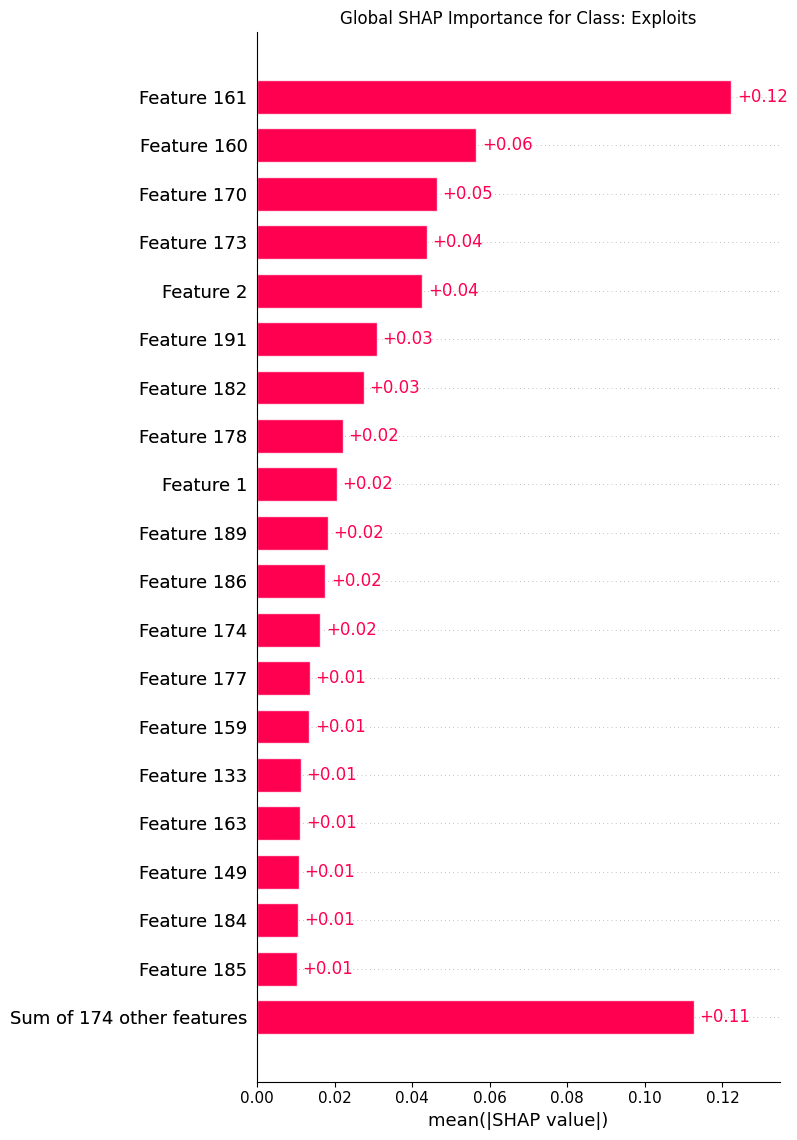

In [64]:
import shap
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_raw) 
class_names = label_encoder.classes_

# Directory fix
os.makedirs("notebooks/explainability", exist_ok=True)

# Step 1: Take a sample from the test set
X_sample = X_test[:100]  # shape: (100, 193)
y_sample = y_test[:100]

# Step 2: Use PermutationExplainer
explainer = shap.Explainer(model, X_sample, algorithm="permutation", feature_names=feature_names)
shap_values = explainer(X_sample)

# Step 3: Choose target class (e.g., "Exploits") and get its index
target_class = "Exploits"
class_idx = list(class_names).index(target_class)

#  Step 4: Extract SHAP values for that class
values = shap_values[..., class_idx].values        # shape: (100, features)
base_values = shap_values[..., class_idx].base_values
data = shap_values.data                            # shape: (100, features)
feature_names = shap_values.feature_names

# Step 5: Wrap into Explanation object
explanation_exploits = shap.Explanation(
    values=values,
    base_values=base_values,
    data=data,
    feature_names=feature_names
)

# Step 6: Plot and save 
plt.figure(figsize=(10, 6))
shap.plots.bar(explanation_exploits, max_display=20, show=False)
plt.title(f"Global SHAP Importance for Class: {target_class}")
plt.tight_layout()
plt.savefig("notebooks/explainability/global_shap_exploits.png")
plt.show()
plt.close()


In [63]:
# Select a test sample index
sample_idx = 10  # Change to any index from 0 to len(X_test)-1

# Extract values for that sample
shap_value = shap_values[sample_idx, :, class_idx]
explanation = shap.Explanation(
    values=shap_value.values,
    base_values=shap_value.base_values,
    data=X_sample[sample_idx],
    feature_names=feature_names
)

# Force plot (optional: save using save_html if using shap.initjs())
shap.initjs()
shap.plots.force(explanation)


In [62]:
import shap
import numpy as np
import os

# Step 1: Make sure output directory exists
output_dir = "force_exploits_samples"
os.makedirs(output_dir, exist_ok=True)

# Step 2: Get predicted classes and true labels
pred_probs = model.predict(X_test)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Step 3: Target class index
target_class = "Exploits"
class_names = np.array(["Analysis", "Backdoor", "DoS", "Exploits", "Fuzzers", "Generic", 
                        "Normal", "Reconnaissance", "Shellcode", "Worms"])
target_idx = np.where(class_names == target_class)[0][0]

# Step 4: Find top samples predicted as Exploits
exploits_indices = np.where(pred_classes == target_idx)[0]
top_indices = exploits_indices[:5]  # Save top 5 only (adjust if needed)

# Step 5: Save SHAP force plots
for i, idx in enumerate(top_indices):
    shap_html = shap.plots.force(
        base_value=shap_values[idx].base_values[target_idx],
        shap_values=shap_values[idx].values[:, target_idx],
        features=shap_values[idx].data,
        feature_names=feature_names,
        matplotlib=False
    )
    filename = os.path.join(output_dir, f"force_plot_exploits_{i+1}_sample{idx}.html")
    shap.save_html(filename, shap_html)

print(f"Saved {len(top_indices)} SHAP force plots to {output_dir}")


386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Saved 5 SHAP force plots to force_exploits_samples


In [ ]:
import os
import shap
import matplotlib.pyplot as plt

# Create output directory if it doesn't exist
output_dir = "notebooks/explainability/force_exploits_samples"
os.makedirs(output_dir, exist_ok=True)

# Loop over top impactful sample indices
for i, idx in enumerate(top_indices):
    # Extract relevant components for this class
    base_value = shap_values[idx].base_values[target_idx]
    shap_value = shap_values[idx].values[:, target_idx]
    feature_vals = shap_values[idx].data
    feature_names = shap_values.feature_names

    # === Save HTML (interactive)
    shap_html = shap.plots.force(
        base_value=base_value,
        shap_values=shap_value,
        features=feature_vals,
        feature_names=feature_names,
        matplotlib=False  # <-- required for interactive HTML
    )
    html_path = os.path.join(output_dir, f"force_plot_exploits_{i+1}_sample{idx}.html")
    shap.save_html(html_path, shap_html)
  

  


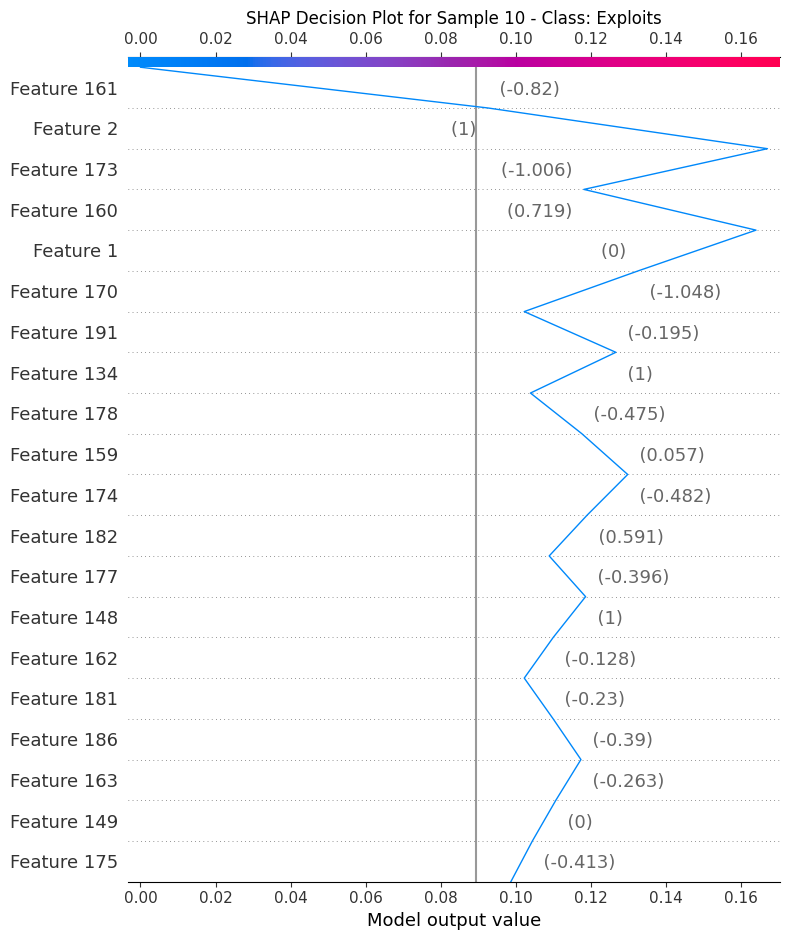

In [ ]:
import shap
import matplotlib.pyplot as plt

# Sample index and class
sample_idx = 10
target_class = "Exploits"
class_idx = list(class_names).index(target_class)

# Extract data from SHAP Explanation
single_shap_value = shap_values[sample_idx].values[:, class_idx]
single_base_value = shap_values[sample_idx].base_values[class_idx]
single_features = shap_values[sample_idx].data

# Dynamically generate fallback feature names
feature_count = single_shap_value.shape[0]  # Should be 193
feature_names = [f"Feature {i}" for i in range(feature_count)]

#  Plot and save
shap.decision_plot(
    base_value=single_base_value,
    shap_values=single_shap_value,
    features=single_features,
    feature_names=feature_names,
    show=False
)

# Save and display
plt.title(f"SHAP Decision Plot for Sample {sample_idx} - Class: {class_names[class_idx]}")
plt.tight_layout()
plt.savefig(f"notebooks/explainability/decision_exploits_sample{sample_idx}.png")
plt.show()


In [61]:
import pandas as pd

# Average absolute SHAP values across all samples 
global_importance = np.abs(shap_values.values[..., class_idx]).mean(axis=0)
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_SHAP": global_importance
}).sort_values("Mean_Abs_SHAP", ascending=False)

# Save to CSV
feature_importance_df.to_csv("notebooks/explainability/global_feature_importance_exploits.csv", index=False)
print("Global feature importances saved.")


Global feature importances saved.


In [ ]:

shap.initjs()

# Generate and save the force plot
sample_idx = 10
force_plot = shap.plots.force(
    base_value=shap_values[sample_idx].base_values[class_idx],
    shap_values=shap_values[sample_idx].values[:, class_idx],
    features=shap_values[sample_idx].data,
    feature_names=feature_names,
    matplotlib=False
)

# Save as HTML
shap.save_html("notebooks/explainability/force_plot_sample10_exploits.html", force_plot)
print("Force plot HTML saved for sample 10.")


Force plot HTML saved for sample 10.


In [59]:
import shap
import numpy as np
import os

# Parameters
sample_size = 100
target_class = "Exploits"
target_idx = list(class_names).index(target_class)

# Predict and filter within the sample
X_sample = X_test[:sample_size]
y_sample = y_test[:sample_size]
pred_probs = model.predict(X_sample)
pred_classes = np.argmax(pred_probs, axis=1)

# Find predicted Exploits in the sample
exploits_indices = np.where(pred_classes == target_idx)[0]
top_indices = exploits_indices[:5]  # or more

# Plot and save SHAP force plots
output_dir = "notebooks/explainability"
os.makedirs(output_dir, exist_ok=True)

for i, idx in enumerate(top_indices):
    shap_html = shap.plots.force(
        base_value=shap_values[idx].base_values[target_idx],
        shap_values=shap_values[idx].values[:, target_idx],
        features=shap_values[idx].data,
        feature_names=feature_names,
        matplotlib=False
    )
    filename = os.path.join(output_dir, f"force_plot_exploits_sample{i+1}.html")
    shap.save_html(filename, shap_html)

print("Saved force plots for Exploits class.")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Saved force plots for Exploits class.


In [58]:
import pandas as pd
import numpy as np

#Calculate mean absolute SHAP values per class
mean_abs_shap_per_class = {}

for i, cls in enumerate(class_names):  # class_names should be ['DoS', 'Exploit', ..., etc.]
    shap_vals_for_class = shap_values[..., i].values  # shape: (samples, features)
    mean_vals = np.mean(np.abs(shap_vals_for_class), axis=0)  # shape: (features,)
    mean_abs_shap_per_class[cls] = mean_vals

# Use fallback feature names if mismatch
expected_feature_count = next(iter(mean_abs_shap_per_class.values())).shape[0]
if len(feature_names) != expected_feature_count:
    print(f"Feature name length mismatch ({len(feature_names)} vs {expected_feature_count}) — using fallback feature names.")
    feature_names = [f"Feature {i}" for i in range(expected_feature_count)]

# Create DataFrame
df_shap_classwise = pd.DataFrame(mean_abs_shap_per_class, index=feature_names)

# Save to CSV
df_shap_classwise.to_csv("notebooks/explainability/mean_shap_values_by_class.csv")
print(" Mean SHAP values saved.")


 Mean SHAP values saved.


In [ ]:
# Plot: Heatmap by Mean SHAP
top_features = df_shap_classwise.abs().mean(axis=1).nlargest(15).index
plt.figure(figsize=(12, 8))
sns.heatmap(df_shap_classwise.loc[top_features], annot=True, fmt=".3f", cmap="coolwarm")
plt.title(" Class-wise Mean Absolute SHAP Values (Top 15 Features)")
plt.tight_layout()
plt.savefig("notebooks/explainability/shap_heatmap_classwise_top15.png")
plt.close()